# Part I - (Ford GoBike System Data Exploration)
## by (ِAbdulmalk Alnajem)

## Introduction
This project explores individual ride data from the Ford GoBike bike-sharing system covering the greater San Francisco Bay area during February 2019. The primary goal is to analyze trip durations, peak usage patterns across hours and days, and differences between user types (Subscribers vs. Customers).

## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.

> Note that the collective size of all your files in the current worksapce **must not exceed 1 GB** in total. 


In [2]:
# Load dataset
df = pd.read_csv('201902-fordgobike-tripdata.csv')

# Create a copy for cleaning
df_clean = df.copy()

# Drop rows with missing values in key features
df_clean.dropna(subset=['member_birth_year', 'member_gender', 'start_station_name', 'end_station_name'], inplace=True)

# Datetime conversions
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'])
df_clean['end_time'] = pd.to_datetime(df_clean['end_time'])

# Feature Engineering: Duration in minutes and Member Age
df_clean['duration_min'] = df_clean['duration_sec'] / 60.0
df_clean['member_age'] = 2019 - df_clean['member_birth_year'].astype(int)
df_clean = df_clean[df_clean['member_age'] <= 80] # Remove age outliers

# Extract time characteristics
df_clean['start_hour'] = df_clean['start_time'].dt.hour
df_clean['start_day'] = df_clean['start_time'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_clean['start_day'] = pd.Categorical(df_clean['start_day'], categories=day_order, ordered=True)

# Display dataset properties
print("Original dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)
df_clean.head(3)

Original dataset shape: (183412, 16)
Clean dataset shape: (174760, 20)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min,member_age,start_hour,start_day
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,869.750000,35,17,Thursday
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,1030.900000,47,12,Thursday
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,608.166667,30,17,Thursday


### What is the structure of your dataset?

> The dataset originally contained **183,412 trips** with **16 features** describing trip duration, start/end timestamps, station details, bike IDs, user classifications, birth years, and genders. After cleaning missing values and age outliers, the dataset contains **174,760 entries**. Most variables are numeric or object types.

### What is/are the main feature(s) of interest in your dataset?

> The main feature of interest is **trip duration** (`duration_min`) and understanding the main factors that influence how long a bike ride lasts.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> * **User Characteristics:** `user_type` (Subscriber vs. Customer), `member_gender`, and calculated `member_age`.
* **Temporal Variables:** Extracted features such as `start_hour` and `start_day` of the week to analyze peak usage periods.

## Univariate Exploration

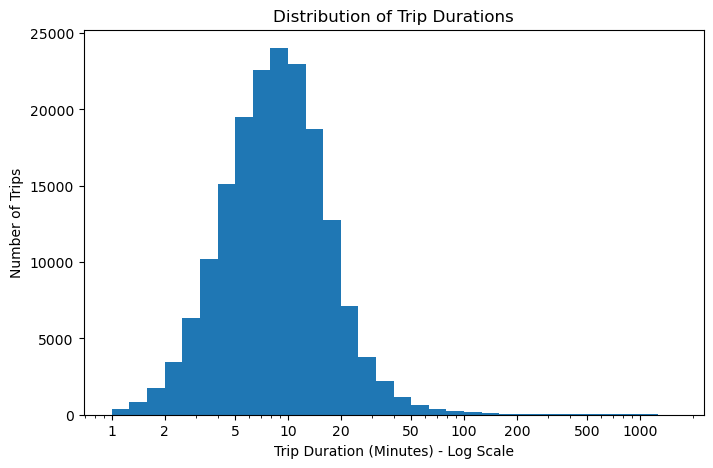

In [3]:
# 1. Question: What is the distribution of trip durations in minutes?

# Visualization
plt.figure(figsize=[8, 5])

# Bin boundaries using log scale
bins = 10 ** np.arange(0, np.log10(df_clean['duration_min'].max()) + 0.1, 0.1)

plt.hist(data=df_clean, x='duration_min', bins=bins, color=sns.color_palette()[0])
plt.xscale('log')
plt.xticks([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000], [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000])

plt.xlabel('Trip Duration (Minutes) - Log Scale')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Durations')

plt.show()

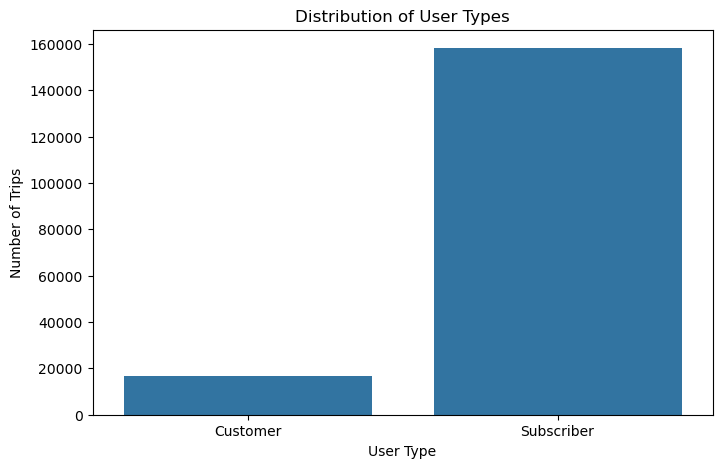

In [4]:
# Question 2: What is the distribution of user types?
plt.figure(figsize=[8, 5])
sns.countplot(data=df_clean, x='user_type', color=sns.color_palette()[0])
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of User Types')
plt.show()

Observations:
- Subscribers make up the vast majority of total users (around 90%), while casual Customers represent a smaller portion of the bike-sharing system users.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> The main variable of interest, trip duration (`duration_min`), initially exhibited a highly right-skewed distribution with a very long right tail, as a few trips lasted several hours while most trips were short. To better understand its pattern, a **log transformation** was applied to the x-axis. On a logarithmic scale, the distribution appears unimodal with a clear peak concentrated between **8 and 12 minutes**, showing that the vast majority of bike trips are brief commutes.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> The main variable of interest, trip duration (`duration_min`), initially exhibited a highly right-skewed distribution with a very long right tail, as a few trips lasted several hours while most trips were short. To better understand its pattern, a **log transformation** was applied to the x-axis. On a logarithmic scale, the distribution appears unimodal with a clear peak concentrated between **8 and 12 minutes**, showing that the vast majority of bike trips are brief commutes.

## Bivariate Exploration

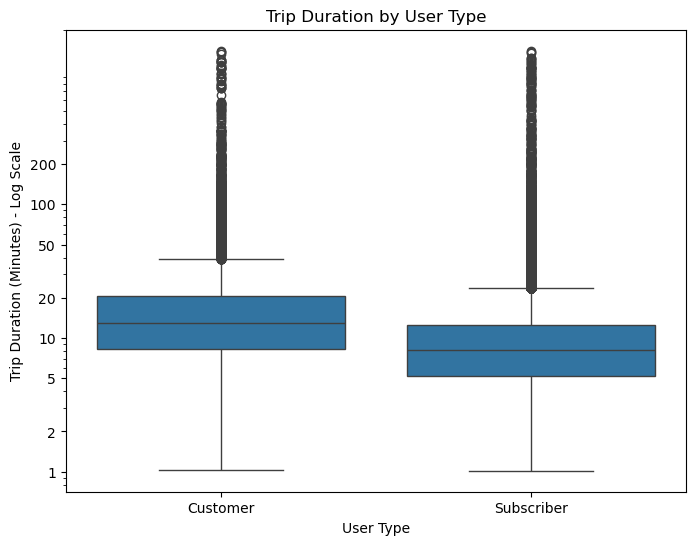

In [5]:
# Question 1: How does trip duration differ between Subscribers and Customers?

plt.figure(figsize=[8, 6])
sns.boxplot(data=df_clean, x='user_type', y='duration_min', color=sns.color_palette()[0])

plt.yscale('log')
plt.yticks([1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200])

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (Minutes) - Log Scale')

plt.show()

**Observations:**
- **Customers** (casual riders) generally take significantly longer trips than **Subscribers** (daily commuters).
- The median duration for Customers is higher (~13 minutes) compared to Subscribers (~8 minutes).
- Subscribers' trip durations are much more consistent and concentrated around short intervals.

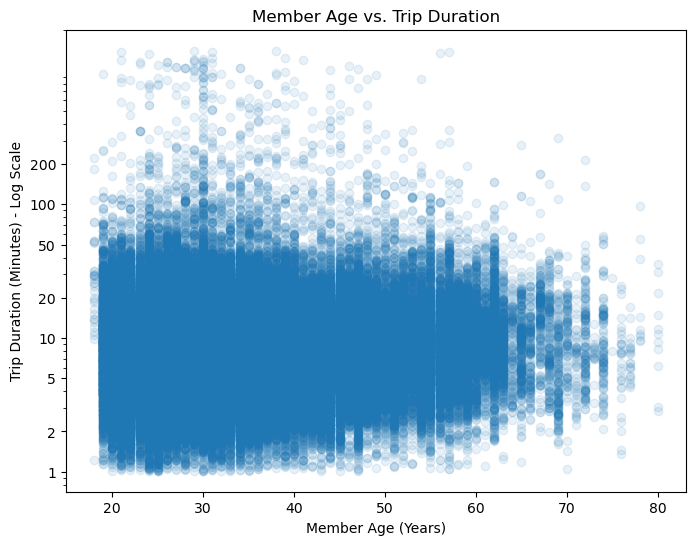

In [6]:
# Question 2: Is there a relationship between member age and trip duration?

plt.figure(figsize=[8, 6])

# Using alpha for transparency to reduce overplotting
plt.scatter(data=df_clean, x='member_age', y='duration_min', alpha=1/10, color=sns.color_palette()[0])

plt.yscale('log')
plt.yticks([1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200])

plt.title('Member Age vs. Trip Duration')
plt.xlabel('Member Age (Years)')
plt.ylabel('Trip Duration (Minutes) - Log Scale')

plt.show()

**Observations:**
- Most trip activity is concentrated among users aged between 20 and 40 years old.
- Longer trip durations (above 50 minutes) are mostly taken by younger users (below 40 years old).
- As member age increases beyond 50 years, the maximum trip duration tends to decrease.

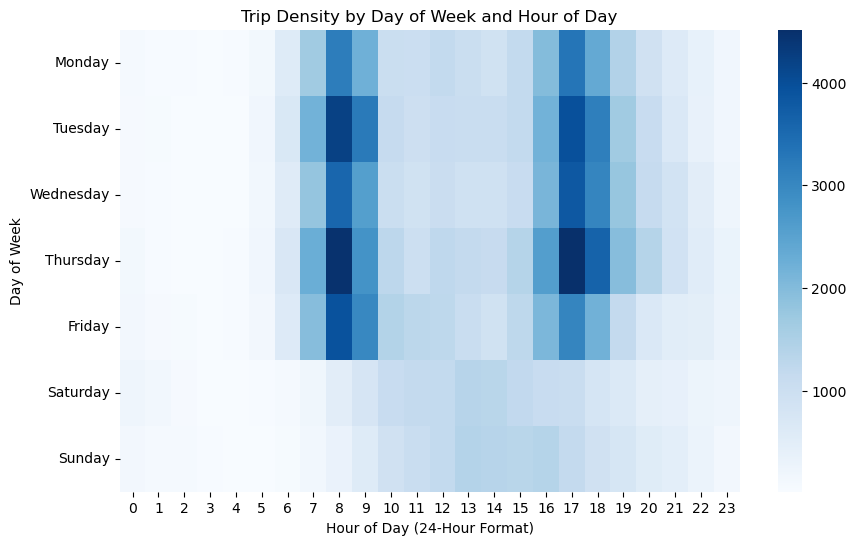

In [7]:
# Question 3: How does bike usage vary by hour across different days of the week?

plt.figure(figsize=[10, 6])

# Group by start day and hour
counts = df_clean.groupby(['start_day', 'start_hour'], observed=False).size().unstack()
sns.heatmap(counts, cmap='Blues')

plt.title('Trip Density by Day of Week and Hour of Day')
plt.xlabel('Hour of Day (24-Hour Format)')
plt.ylabel('Day of Week')

plt.show()

**Observations:**
- A clear **bimodal rush-hour pattern** appears on weekdays (Monday through Friday) around **8 AM** and **5 PM**.
- On weekends (Saturday and Sunday), usage shifts to a single continuous peak between **11 AM and 4 PM**, reflecting leisure usage.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> 1. **Trip Duration vs. User Type:** Casual Customers take longer trips on average compared to Subscribers who mostly use bikes for short, predictable daily commute trips.
2. **Trip Duration vs. Age:** Younger riders take a wider range of trip durations, including longer rides, while older riders stick primarily to shorter trips.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Yes, analyzing `start_hour` and `start_day` revealed distinct behavioral patterns: weekday usage is dominated by morning/evening commute spikes, whereas weekend usage is evenly spread throughout midday hours.

## Multivariate Exploration

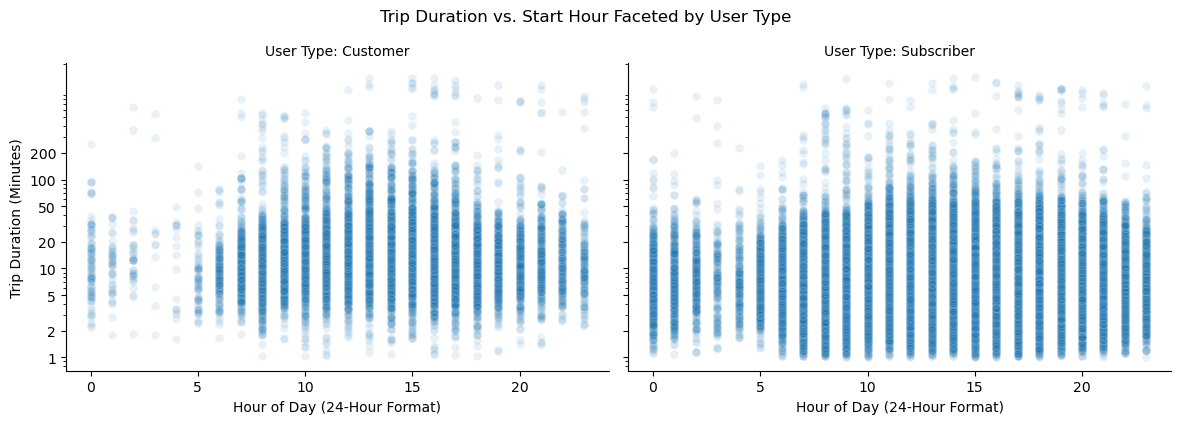

In [8]:
# Question 1: How does the relationship between start hour and trip duration differ across user types?

g = sns.FacetGrid(data=df_clean, col='user_type', height=4, aspect=1.5)
g.map(sns.scatterplot, 'start_hour', 'duration_min', alpha=1/10, color=sns.color_palette()[0])

g.set_axis_labels('Hour of Day (24-Hour Format)', 'Trip Duration (Minutes)')
g.set_titles(col_template='User Type: {col_name}')
plt.yscale('log')
plt.yticks([1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200])

plt.suptitle('Trip Duration vs. Start Hour Faceted by User Type', y=1.05)
plt.show()

**Observations:**
- **Subscribers** exhibit sharp hourly clusters concentrated specifically around 8 AM and 5 PM, maintaining mostly short trip durations (< 20 mins).
- **Customers** show a much broader distribution throughout the day (between 10 AM and 6 PM), with a higher concentration of long-duration trips (> 30 mins) across all hours.

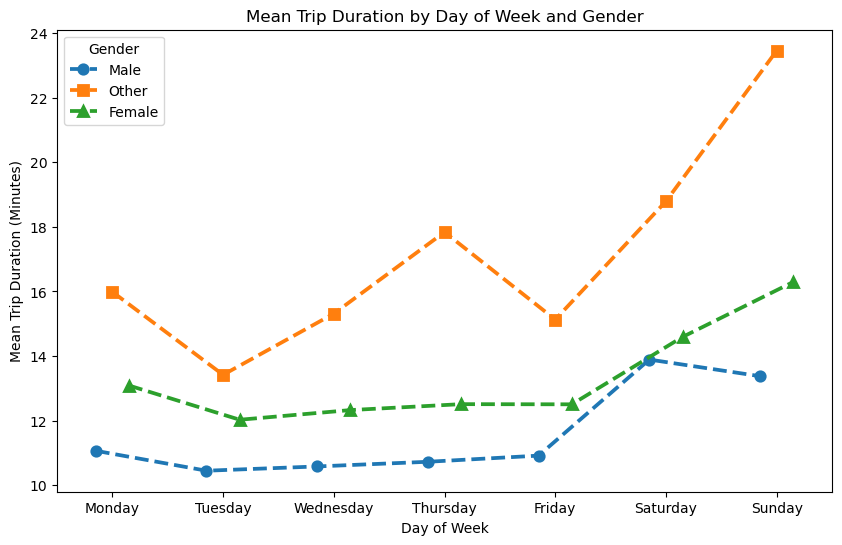

In [9]:
# Question 2: How do member gender and days of the week interact to affect average trip durations?

plt.figure(figsize=[10, 6])

sns.pointplot(data=df_clean, x='start_day', y='duration_min', hue='member_gender',
              dodge=0.3, linestyles='--', markers=['o', 's', '^'], errorbar=None)

plt.title('Mean Trip Duration by Day of Week and Gender')
plt.xlabel('Day of Week')
plt.ylabel('Mean Trip Duration (Minutes)')
plt.legend(title='Gender')

plt.show()

**Observations:**
- **Female riders** and **Other gender riders** consistently have slightly higher average trip durations compared to **Male riders** across all days of the week.
- All gender groups display a similar upward trend in average trip duration during weekends (Saturday and Sunday).

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> Combining `member_gender`, `start_day`, and `duration_min` helped reveal demographic patterns:
1. **User Types:** Subscribers predominantly take short, routine commuting trips during weekday rush hours, whereas Customers use the service for longer leisure rides across all days.
2. **Gender Differences:** Female and Other gender riders consistently record slightly higher average trip durations than Male riders across all days of the week.
3. **Weekend Effect:** All gender categories show an increase in average trip duration during weekends, indicating more relaxed, leisure-oriented riding habits.

### Were there any interesting or surprising interactions between features?

> An interesting interaction is that while Male riders constitute the vast majority of total trips, Female and Other gender riders consistently record longer average trip durations across all days of the week. Additionally, the weekend increase in average duration is surprisingly consistent across all gender groups, showing that leisure riding patterns shift universally on weekends regardless of gender.

## Conclusions
> ### Summary of Key Findings
1. **Trip Duration:** Most bike trips are short, with a unimodal log-normal distribution centered around **8 to 12 minutes**.
2. **Peak Usage Times:** On weekdays, peak bike usage clearly aligns with standard work commuting hours (**8:00 AM** and **5:00 PM**). On weekends, demand is spread evenly throughout midday hours (**11:00 AM – 4:00 PM**).
3. **Subscribers vs. Customers:** 
   - **Subscribers** form the majority of users and take shorter, highly regular trips for commuting.
   - **Customers** make up a smaller proportion of users but spend significantly more time per ride (averaging 20–25 minutes).
4. **Demographic Insights:** Female riders and Other gender categories log slightly longer average trip durations compared to Male riders across all days.

### Reflection on the Exploration Process
- **Data Cleaning:** Removing missing values in user demographics and filtering out age outliers ($\le$ 80 years old) preserved dataset integrity.
- **Transformations:** Applying a log scale to `duration_min` was essential to reveal the underlying unimodal distribution that was previously hidden by long-tailed outliers.
- **Feature Engineering:** Creating `duration_min`, `member_age`, `start_hour`, and `start_day` allowed for meaningful multi-dimensional exploration across univariate, bivariate, and multivariate visualizations.